<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/Linear_and_Exponential_Regression_Model" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression

This notebook is an implementation of both linear and logistic regression

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [1]:
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

###Linear Regression


We will use the pokemon data set for this project.

In [2]:
pokemon_link = 'https://raw.githubusercontent.com/nurfnick/Data_Sets_For_Stats/master/CuratedDataSets/pokemon.csv'
pokemon = pd.read_csv(pokemon_link)
pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


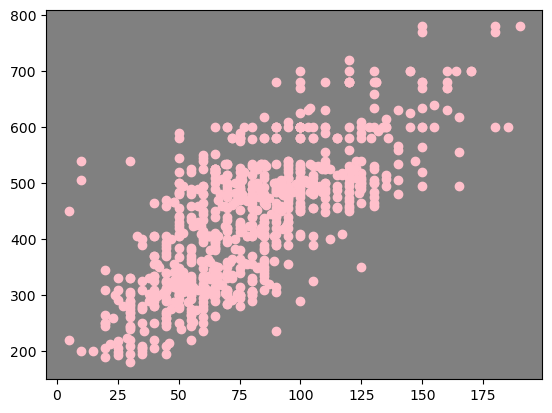

In [3]:
ax = plt.axes()
ax.set_facecolor('grey')
plt.scatter(pokemon['Attack'], pokemon['Total'], c='pink')

Below we have created a functions to calculate the components of our linear regression equation.


In [4]:
def average(list1):
  return sum(list1)/len(list1)

def square_sum(list1, list2):
  sum = 0
  for i in range(len(list1)):
    sum = sum + list1[i]*list2[i]
  return sum

In [5]:
x_bar = average(pokemon['Attack'])
y_bar = average(pokemon['Total'])
length = len(pokemon['Attack'])

Sxy = square_sum(pokemon['Attack'],pokemon['Total'])-length*x_bar*y_bar
Sxx = square_sum(pokemon['Attack'], pokemon['Attack'])-length*x_bar**2

x_bar = average(pokemon['Attack'])
y_bar = average(pokemon['Total'])


In [6]:
a_1 = Sxy/Sxx
a_0 = y_bar-a_1*x_bar
print(f'Our slope: {a_1}')
print(f'Our intercept: {a_0}')

Our slope: 2.7210485308267214
Our intercept: 220.1362647540255


Now, we have created a function for computing predictions using our regression.

$$y=2.721049x+220.136265$$

In [7]:
def line(slope, intercept, input):
  return slope*input + intercept

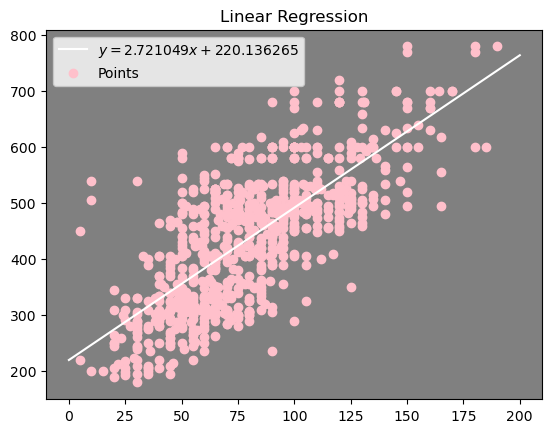

In [8]:
x = np.arange(0, 225, 25)
ax = plt.axes()
ax.set_facecolor('grey')
plt.plot(x, line(a_1, a_0, x), c = 'white')
plt.scatter(pokemon['Attack'], pokemon['Total'], c = 'pink')
plt.title('Linear Regression')
plt.legend(['$y=2.721049x+220.136265$', 'Points'])

We have computed the sum of squares error for our predictions.

In [9]:
def SSE(col1, col2):
  sse = 0
  for i in range(len(col1)):
    sse = sse + (col1[i]-col2[i])**2
  return sse

In [10]:
SSE(pokemon['Attack'], pokemon['Total'])

np.int64(109205943)

Below we have checked our work using a package. As you can see our calculations are correct.


In [11]:
slope = stats.linregress(pokemon['Attack'],pokemon['Total'])[0]
intercept = stats.linregress(pokemon['Attack'],pokemon['Total'])[1]
print(f'Stats package slope: {slope}')
print(f'Stats package intercept: {intercept}')

Stats package slope: 2.721048530826724
Stats package intercept: 220.1362647540253


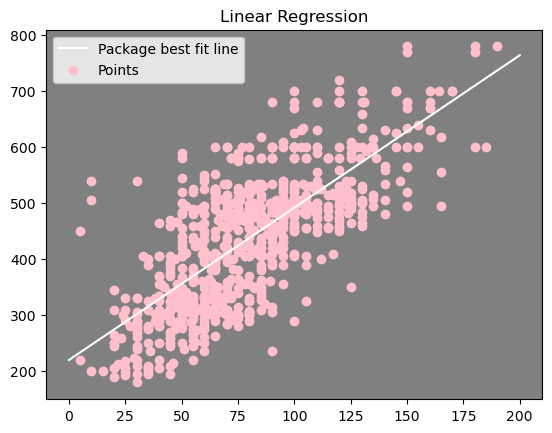

In [12]:
ax = plt.axes()
ax.set_facecolor('grey')
plt.plot(x, line(slope, intercept, x), c = 'white')
plt.scatter(pokemon['Attack'], pokemon['Total'], c = 'pink')
plt.title('Linear Regression')
plt.legend(['Package best fit line', 'Points'])

###Nonlinear Regression

We will use the data columns Generation and HP. We hypothesize that the relationship is exponential.

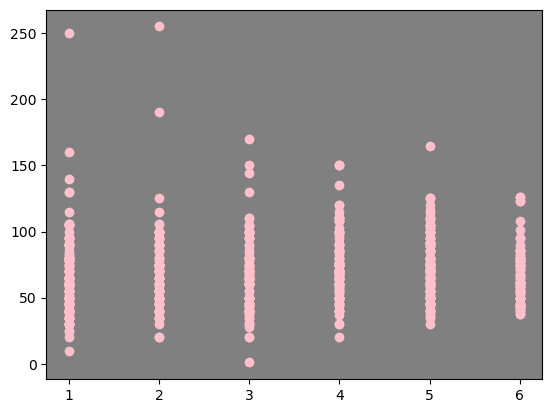

In [13]:
ax = plt.axes()
ax.set_facecolor('grey')
plt.scatter(pokemon['Generation'], pokemon['HP'], c='pink')

Choosing exponential regression

$$y=Ae^{bx}$$

In [14]:
def sum3(list1, list2, list3):
  sum = 0
  for i in range(len(list1)):
    sum = sum + list1[i]*list2[i]*list3[i]
  return sum

Creating exponential function calculation

$$f(b)=\sum\limits_{i=1}^{n}y_ix_ie^{bx_i}
-\frac{\sum\limits_{i=1}^{n}y_ie^{bx_i}}
{\sum\limits_{i=1}^{n}e^{2bx_i}}
\sum\limits_{i=1}^{n}x_ie^{2bx_i}
=0$$

and $$A=\frac{\sum\limits_{i=1}^{n}y_ie^{bx_i}}
{\sum\limits_{i=1}^{n}e^{2bx_i}}
$$

In [15]:
function = lambda b: sum3(pokemon['HP'],pokemon['Generation'],np.exp(b*pokemon['Generation'])) \
  -square_sum(pokemon['HP'],np.exp(b*pokemon['Generation']))/sum(np.exp(2*b*pokemon['Generation'])) \
  *square_sum(pokemon['Generation'],np.exp(2*b*pokemon['Generation']))

Must solve this nonlinear equation for $b$. We will use the secant method function we created in project part 3, and some error functions from project part 1

The below equation is used for the secant method. $$x_{i+1}=x_i-\frac{f(x_i)(x_i-x_{i-1})}{f(x_i)-f(x_{i-1})}$$
This method requires two initial guesses and typically converges slower than the Newton-Raphson method.

Below is an algorithm for finding roots using the secant method.

In [16]:
def approx_error(present_approx, previous_approx):
  return present_approx - previous_approx

def relative_error_percent(present_approx, previous_approx):
  return abs(approx_error(previous_approx, present_approx) / present_approx)*100

In [17]:
iterations1 = []
error_list = []

def secant(function, guess_one, guess_two):
  root = guess_two - (function(guess_two)*(guess_two - guess_one))/(function(guess_two) - function(guess_one))
  return root

def secant_method(function, first_value, second_value, iterations):
  x = [first_value, second_value]
  for i in range(iterations):
    x.append(secant(function,x[-2],x[-1]))
    error = relative_error_percent(x[-1], x[-2])
    error_list.append(error)
  return x

In [18]:
sec = secant_method(function, 0.00001, 0.0001, 20)
secant_approx1 = {'First Value': [i for i in sec[:4]]}
secant_approx2 = {'Second Value': [i for i in sec[1:5]]}
secant_approx3 = {'Output': [i for i in sec[2:6]]}
error_approx = {'Error': [i for i in error_list[:4]]}

secant_table1 = pd.DataFrame(secant_approx1)
secant_table2 = pd.DataFrame(secant_approx2)
secant_table3 = pd.DataFrame(secant_approx3)
error_table = pd.DataFrame(error_approx)

result = pd.concat([secant_table1, secant_table2, secant_table3, error_table],axis=1)
print(result)

/tmp/ipykernel_4494/1462631580.py:5: RuntimeWarning: invalid value encountered in scalar divide
  root = guess_two - (function(guess_two)*(guess_two - guess_one))/(function(guess_two) - function(guess_one))


   First Value  Second Value    Output      Error
0     0.000010      0.000100  0.013427  99.255219
1     0.000100      0.013427  0.012825   4.694623
2     0.013427      0.012825  0.012850   0.194665
3     0.012825      0.012850  0.012850   0.000372


The table tells us that using the coefficient $b=0.012850$ will give us an error of $0.03%$. We would show more iterations but python will only print to the 6th decimal place, so that is the best approximation we can find.

Now that we have b, we plug it into A to finish our regression equation.
$$A=\frac{\sum\limits_{i=1}^{n}y_ie^{(0.012850)x_i}}
{\sum\limits_{i=1}^{n}e^{2(0.012850)x_i}}
$$

In [19]:
A = lambda b:square_sum(pokemon['HP'],np.exp(b*pokemon['Generation']))/sum(np.exp(2*b*pokemon['Generation']))
b = 0.012850
A_approx = A(b)

$$A = 66.34807671788961$$

Lets plug this into our regression equation and see how it matches up with the data points!

$$y=66.348077e^{0.012850x}$$

In [20]:
def exp_line(A, coefficient, points):
  return A*np.exp(coefficient*points)

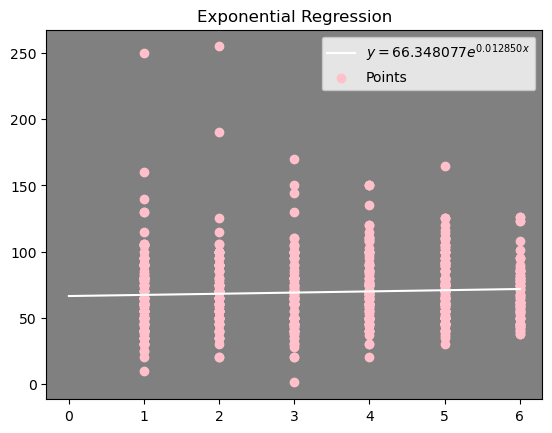

In [21]:
x = np.arange(0, 7, 1)
ax = plt.axes()
ax.set_facecolor('grey')
plt.plot(x, exp_line(A_approx, b, x), c='white')
plt.scatter(pokemon['Generation'], pokemon['HP'], c='pink')
plt.title('Exponential Regression')
plt.legend(['$y=66.348077e^{0.012850x}$', 'Points'])

###Findings

From our linear regression line, you can see that the relationship between ATK and Total stats is positive. As Total stats go up, ATK usually goes up as well.
It seems like Linear regression was very appropriate to use here. An intercept of ~220 seems very fitting for the data given, and the slope generally follows the data given.

The fit of our nonlinear regression isn't great, but it's possible it couldn't get better. Our graph has values only at integers of x, so any solid line would be inappropriate to represent this data. However, something more simliar to a wave might've come closer to the data given. We ended up using the secant method to find our roots, which did work in the end.